# Functions

In [1]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns

from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope

date = datetime.today().strftime('%Y%m%d')
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

import warnings
warnings.filterwarnings("ignore")


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 18.92it/s]

Numba compilation complete!


In [2]:
def chartplottingdabest(dfi, basegenotype, parameter):
    
    dfr1 = pd.DataFrame()
    for names in basegenotype:
        dfrr = pd.DataFrame()
        filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
        filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

        dfrr[names + " Cntrl" ] = filter2[parameter]
        dfrr[names] = filter1[parameter]
        dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfr1.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    
    test = dabest.load(dfr1, idx=titlelst)    
    tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)
    
    arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

    newlist = []
    for n in arrangedsorting['test']:
        newlist.append((n +" Cntrl", n))

    return dfr1, arrangedsorting['test'], newlist

def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr[names + " Cntrl" ] = filter2[parameter]
    dfrr[names] = filter1[parameter]
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst)    
    
    return test

# Code

In [3]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = officecomp

root = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_test\\"

In [7]:
responder = "ACR"
filepath = root + "20250310_" + responder + "_totalcompilation.csv"
df2= pd.read_csv(filepath)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

In [5]:
dfpi, sortedlist, dabestlist = chartplottingdabest(dfi, basegenotype, 'pi_smoothed_Pattern 01')
dfspeed, notsortedlist, notdabestlist = chartplottingdabest(dfi, basegenotype, 'log2_pace_ratio_Pattern 01')

In [10]:
dfr1 = pd.DataFrame()

dfrr = pd.DataFrame()
filter1 = dfi[(dfi['MBON'] == "SS75200") & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
filter2 = dfi[(dfi['MBON'] == "SS75200") & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

dfrr["SS75200" + " Cntrl" ] = filter2['pi_smoothed_Pattern 01']
dfrr["SS75200"] = filter1['pi_smoothed_Pattern 01']
dfr1 = pd.concat([dfr1, dfrr], axis = 1)
    
l = dfr1.columns.tolist()
titlelst = list(zip(l,l[1:]))[::2]  

test = dabest.load(dfr1, idx=titlelst)    
tab = pd.concat([test.hedges_g.results['test'], test.hedges_g.results['difference']], axis = 1)

arrangedsorting = tab.sort_values(by=['difference'], ascending = True).reset_index(drop=True)

arrangedsorting

,test,difference
0,SS75200,-0.236673


In [19]:
testables

,Unnamed: 0,flyid,exptDate,MBON,expt_time_start,genotype,opsin,light_intensity,light_color,status,...,light_attraction_index_baseline_corrected,pi_smoothed_baseline_corrected,light_attraction_index_not_baseline_corrected,pi_smoothed_not_baseline_corrected,reversals_to_light,traversals_to_light,reversals_to_dark,traversals_to_dark,reversal_light_pi,traversal_light_pi
0,483,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.033333,-0.214659,-0.066667,-0.429318,2.0,2.0,2.0,2.0,0.0,0.000000
1,484,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.250000,-0.036857,-0.500000,-0.073715,0.0,1.0,0.0,2.0,NaN,-0.333333
2,485,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.077778,-0.199667,-0.155556,-0.399334,0.0,6.0,1.0,7.0,-1.0,-0.076923
3,486,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,0.000000,0.026344,0.000000,0.052687,1.0,4.0,0.0,5.0,1.0,-0.111111
4,487,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.007937,-0.038111,-0.015873,-0.076222,0.0,8.0,0.0,8.0,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,654,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1.0,NaN
392,655,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,-0.500000,NaN,-1.000000,0.0,0.0,0.0,0.0,NaN,NaN
393,656,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,-0.500000,0.189891,0.000000,0.379781,3.0,0.0,3.0,0.0,0.0,NaN
394,657,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,-0.250000,-0.142170,-0.500000,-0.284341,0.0,1.0,1.0,2.0,-1.0,-0.333333


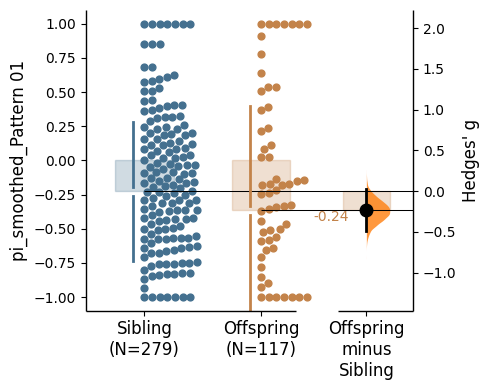

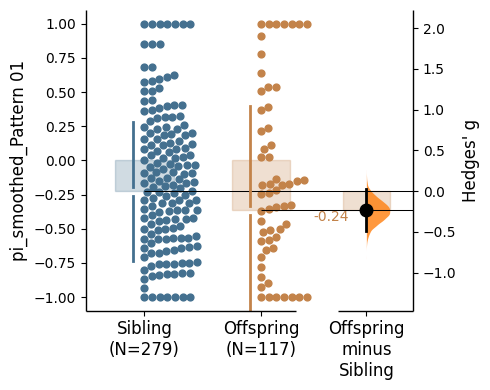

In [24]:
df1 = testables[(testables['light_intensity']=='Full')].loc[:,['MBON', 'light_intensity','status','pi_smoothed_Pattern 01']].reset_index(drop=True)

dbsample = dabest.load(df1[(df1['MBON'] == "SS75200")].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01");
dbsample.hedges_g.plot()

In [23]:
testables[(testables['light_intensity']=='Full')]

,Unnamed: 0,flyid,exptDate,MBON,expt_time_start,genotype,opsin,light_intensity,light_color,status,...,light_attraction_index_baseline_corrected,pi_smoothed_baseline_corrected,light_attraction_index_not_baseline_corrected,pi_smoothed_not_baseline_corrected,reversals_to_light,traversals_to_light,reversals_to_dark,traversals_to_dark,reversal_light_pi,traversal_light_pi
0,483,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.033333,-0.214659,-0.066667,-0.429318,2.0,2.0,2.0,2.0,0.0,0.000000
1,484,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.250000,-0.036857,-0.500000,-0.073715,0.0,1.0,0.0,2.0,NaN,-0.333333
2,485,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.077778,-0.199667,-0.155556,-0.399334,0.0,6.0,1.0,7.0,-1.0,-0.076923
3,486,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,0.000000,0.026344,0.000000,0.052687,1.0,4.0,0.0,5.0,1.0,-0.111111
4,487,SS75200_GtACR1_w1118 x ACR_Full_Sibling_2021-0...,2021-08-10,SS75200,11-36-34,w1118 x ACR,GtACR1,Full,Green,Sibling,...,-0.007937,-0.038111,-0.015873,-0.076222,0.0,8.0,0.0,8.0,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,654,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1.0,NaN
392,655,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,-0.500000,NaN,-1.000000,0.0,0.0,0.0,0.0,NaN,NaN
393,656,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,-0.500000,0.189891,0.000000,0.379781,3.0,0.0,3.0,0.0,0.0,NaN
394,657,SS75200_Chrimson_SS75200 x Chrimson2_Full_Offs...,2024-05-12,SS75200,17-21-46,SS75200 x Chrimson2,Chrimson,Full,Red,Offspring,...,-0.250000,-0.142170,-0.500000,-0.284341,0.0,1.0,1.0,2.0,-1.0,-0.333333


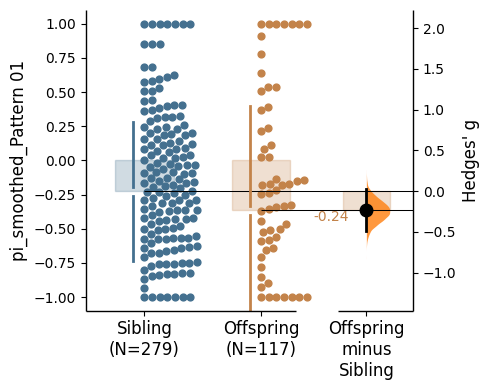

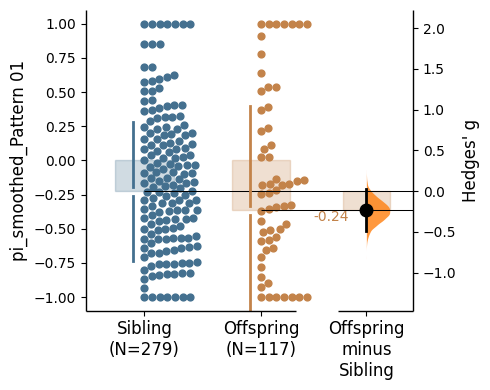

In [18]:
testables = dfi[dfi['MBON'] == "SS75200"].reset_index(drop=True)

dbfeature = dabest.load(testables[(testables['MBON'] == "SS75200")].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01");
dbfeature.hedges_g.plot()

In [6]:
piplot = dabest.load(dfpi, idx=dabestlist)
spplot = dabest.load(dfspeed, idx=dabestlist)

Text(0.5, 0.98, 'MBONS > ACR')

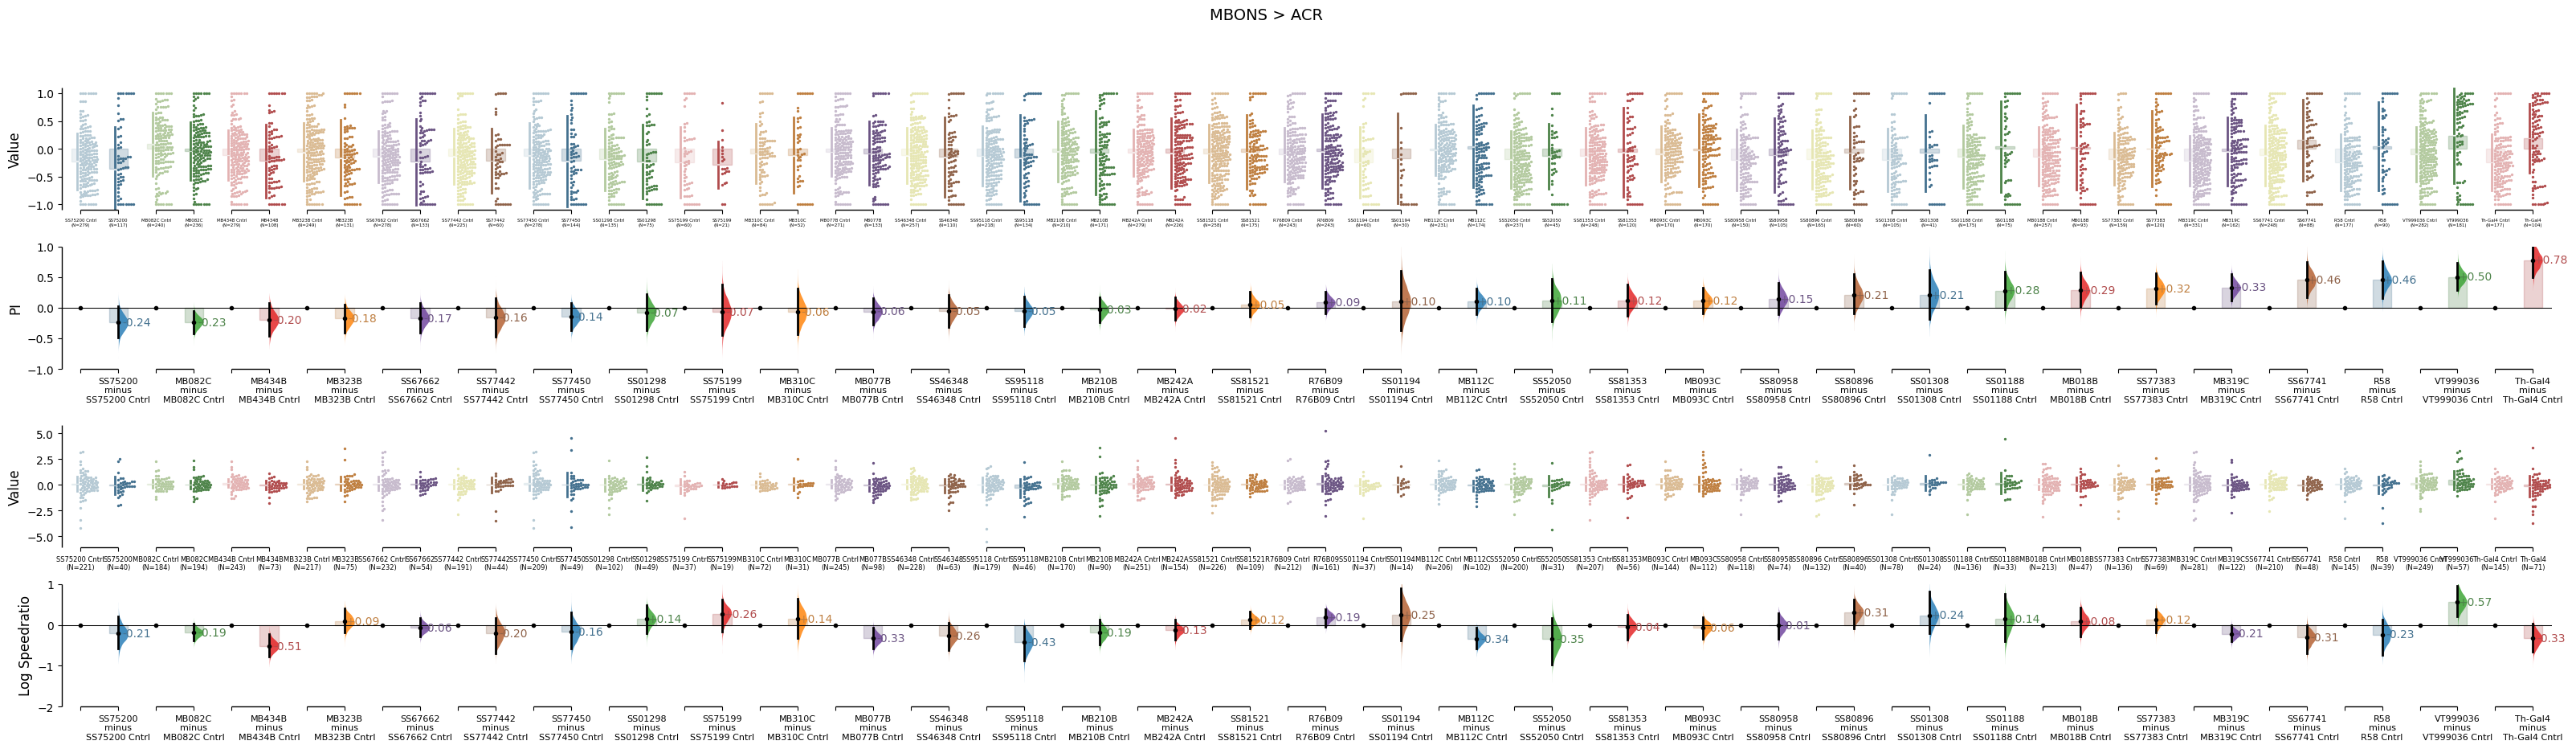

In [7]:
f, axx = plt.subplots(nrows=2, ncols=1,
                    figsize=(40
                             ,10) # ensure proper width-wise spacing.
                   )
piplot.hedges_g.plot(fontsize_rawxlabel=4, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=0.5, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="PI", contrast_ylim=(-1,1), ax=axx.flat[0]);

spplot.hedges_g.plot(fontsize_rawxlabel=6, fontsize_contrastxlabel=8, float_contrast=False, raw_marker_size=0.5, contrast_marker_size=3, 
                      custom_palette="Paired", contrast_label="Log Speedratio", contrast_ylim=(-2,1), ax=axx.flat[1]);

f.suptitle ("MBONS > " + responder, fontsize = 14)

#sns.set(font_scale=0.5,  style='ticks')

In [19]:
imagefile = root + "\\images\\compiled PI and Speed OSAR plots at full light intensity_" + responder + '_' + date
f.savefig(imagefile + '.svg', bbox_inches="tight", dpi=600)

## forest plot

In [4]:
from dabest.forest_plot import forest_plot
compiled = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_test\\20250310_ACR_totalcompilation.csv"
dfcompiled= pd.read_csv(compiled)

In [5]:
dfcompiled

,Unnamed: 0,flyid,exptDate,driver,expt_time_start,genotype,opsin,light_intensity,light_color,status,...,light_attraction_index_baseline_corrected,pi_smoothed_baseline_corrected,light_attraction_index_not_baseline_corrected,pi_smoothed_not_baseline_corrected,reversals_to_light,traversals_to_light,reversals_to_dark,traversals_to_dark,reversal_light_pi,traversal_light_pi
0,0,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,...,-0.085714,-0.007146,-0.171429,-0.014293,2.0,3.0,4.0,3.0,-0.333333,0.0
1,1,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,...,-0.050000,-0.057047,-0.100000,-0.114094,1.0,3.0,2.0,3.0,-0.333333,0.0
2,2,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,...,0.035714,0.111217,0.071429,0.222433,1.0,4.0,0.0,4.0,1.000000,0.0
3,3,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,...,0.200000,-0.061613,0.400000,-0.123226,2.0,1.0,3.0,0.0,-0.200000,1.0
4,4,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,...,0.125000,-0.067838,0.250000,-0.135675,1.0,3.0,2.0,1.0,-0.333333,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43658,719,VT999036_Chrimson_VT999036 x Chrimson2_Full_Of...,2024-07-07,VT999036,18-42-35,VT999036 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,0.000000,NaN,0.000000,0.0,0.0,0.0,0.0,NaN,NaN
43659,720,VT999036_Chrimson_VT999036 x Chrimson2_Full_Of...,2024-07-07,VT999036,18-42-35,VT999036 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,-0.500000,NaN,-1.000000,0.0,0.0,0.0,0.0,NaN,NaN
43660,721,VT999036_Chrimson_VT999036 x Chrimson2_Full_Of...,2024-07-07,VT999036,18-42-35,VT999036 x Chrimson2,Chrimson,Full,Red,Offspring,...,NaN,-0.500000,NaN,-1.000000,0.0,0.0,0.0,0.0,NaN,NaN
43661,722,VT999036_Chrimson_VT999036 x Chrimson2_Full_Of...,2024-07-07,VT999036,18-42-35,VT999036 x Chrimson2,Chrimson,Full,Red,Offspring,...,-1.000000,-0.500000,-1.000000,-1.000000,0.0,0.0,1.0,0.0,-1.000000,NaN


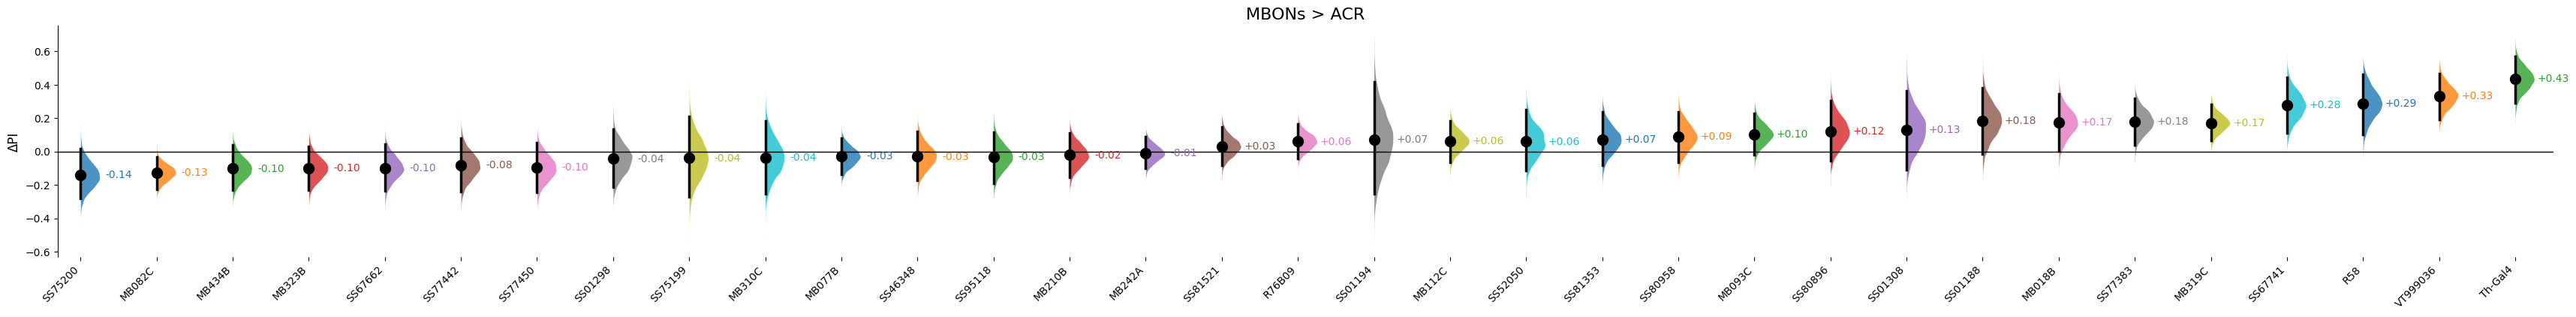

In [15]:
#df1 = dfcompiled[(dfcompiled['light_intensity']=='Full')].loc[:,['driver','light_intensity','status','pi_smoothed_Pattern 01', 'reversal_light_pi', 'traversal_light_pi', 'light_attraction_index_Pattern 01', 'log2_pace_ratio_Pattern 01']].reset_index(drop=True)
df1 = dfcompiled[(dfcompiled['light_intensity']=='Full')].loc[:,['driver','light_intensity','status','pi_smoothed_Pattern 01']].reset_index(drop=True)

lst = []
names =[]
sorteddf = pd.DataFrame()

for n in df1['driver'].unique().tolist():
    dbfeature = dabest.load(df1[(df1['driver'] == n)].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01")
    tempdf = pd.DataFrame()
    tempdf['MBON'] = [n]
    tempdf['difference']= [float(dbfeature.hedges_g.statistical_tests.difference)]
    sorteddf = pd.concat([sorteddf, tempdf], axis =0)

sorteddf = sorteddf.sort_values(by=['difference']).reset_index(drop=True)


for n in sorteddf['MBON']:
    tempdf1 = df1[(df1['driver'] == n)].reset_index(drop=True)
    dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y="pi_smoothed_Pattern 01")
    lst.append(dbfeature)
    names.append(n)
  

forest1_horizontal2 = forest_plot(data = lst, effect_size= "mean_diff", labels = names, idx=[[0]]*len(names), ylabel= "ΔPI", title = "MBONs > " + responder);

## Addition of singular plots

In [13]:
filepath = root + "20250310_" + responder + "_totalcompilation.csv"
df2= pd.read_csv(filepath, index_col=0)

basegenotype = df2['driver'].unique()

#dfi=df2[(df2['light_intensity']=='Half') | (df2['light_intensity']=='Full')].copy()
dfi=df2[(df2['light_intensity']=='Full')].copy()
dfi.replace([np.inf, -np.inf], np.nan, inplace=True)
dfi.rename(columns={'driver': 'MBON'}, inplace = True)

basegenotype

array(['MB018B', 'MB077B', 'MB082C', 'MB093C', 'MB112C', 'MB210B',
       'MB242A', 'MB310C', 'MB319C', 'MB323B', 'MB434B', 'R58', 'R76B09',
       'SS01188', 'SS01194', 'SS01298', 'SS01308', 'SS46348', 'SS52050',
       'SS67662', 'SS67741', 'SS75199', 'SS75200', 'SS77383', 'SS77442',
       'SS77450', 'SS80896', 'SS80958', 'SS81353', 'SS81521', 'SS95118',
       'Th-Gal4', 'VT999036'], dtype=object)

In [14]:
basegenotype = ["SS75200"]

In [15]:
def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['MBON'] == names) & (dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr[names + " Cntrl" ] = filter2[parameter]
    dfrr[names] = filter1[parameter]
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst)    
    
    return test

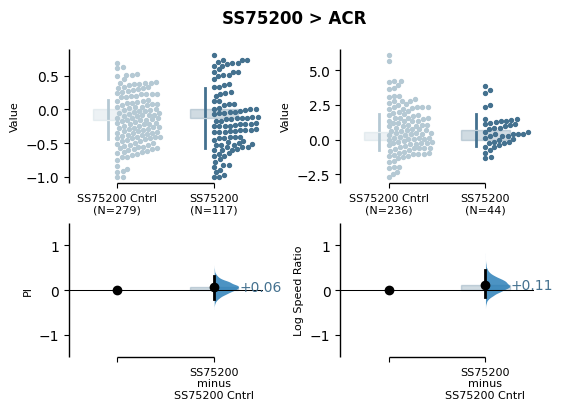

In [16]:
for n in basegenotype:
   
   figure2, axx = plt.subplots(nrows=1, ncols=2,
                    figsize=(6
                             ,4), gridspec_kw={'wspace': 0.4}
                                # ensure proper width-wise spacing.
                   )

   singleplottingdabest(dfi, n, "pi_smoothed_Pattern 01_baseline_corrected").hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                         custom_palette="Paired", contrast_label="PI", contrast_ylim=(-1.5,1.5), ax=axx.flat[0]);

   singleplottingdabest(dfi, n, "log2_speed_ratio_Pattern 01").hedges_g.plot(float_contrast=False, fontsize_rawylabel=8,fontsize_rawxlabel=8, 
        fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                        custom_palette="Paired", contrast_label="Log Speed Ratio", contrast_ylim=(-1.5,1.5), ax=axx.flat[1]);

   figure2.tight_layout()
   figure2.suptitle( n + " > " + responder, fontweight='bold', size = 12, y=0.98)

   #filesaving
   # filename = folderpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2024images\\" +  n + " x " + genot + '_OSAR_Full_light'
   # figure2.savefig(filename + '.svg', bbox_inches="tight", dpi=600)

